In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

In [52]:
df = pd.read_csv('customer_clean.csv')

In [53]:
df['created_date']  = pd.to_datetime(df['created_date'],  dayfirst=False, errors='coerce')
df['canceled_date'] = pd.to_datetime(df['canceled_date'], dayfirst=False, errors='coerce')


In [54]:
NOW = pd.Timestamp('2025-04-01')

if 'churn_flag' not in df.columns:
    df['churn_flag'] = df['canceled_date'].notna().astype(int)
if 'active_flag' not in df.columns:
    df['active_flag'] = 1 - df['churn_flag']
if 'subscription_status' not in df.columns:
    df['subscription_status'] = np.where(df['churn_flag'] == 1, 'Cancelled', 'Active')
if 'was_subscription_paid' not in df.columns:
    df['was_subscription_paid'] = df['was_subscription_paid'].astype(bool) \
        if 'was_subscription_paid' in df.columns else True
df['was_subscription_paid'] = df['was_subscription_paid'].astype(bool)

if 'monthly_revenue' not in df.columns:
    mo_map = {'monthly': 1, 'quarterly': 3, 'annual': 12, 'biannual': 24}
    df['monthly_revenue'] = df.apply(
        lambda r: r['subscription_cost'] / mo_map.get(str(r['subscription_interval']).lower(), 1),
        axis=1)

if 'subscription_duration' not in df.columns:
    end = df['canceled_date'].fillna(NOW)
    df['subscription_duration'] = ((end - df['created_date']).dt.days / 30.44).clip(lower=1)

if 'Revenue' not in df.columns:
    df['Revenue'] = np.where(df['was_subscription_paid'], df['subscription_cost'], 0.0)

if 'clv_per_customer' not in df.columns:
    df['clv_per_customer'] = df['Revenue'] * df['subscription_duration']

if 'cohort_month' not in df.columns:
    df['cohort_month'] = df['created_date'].dt.to_period('M')

if 'months_since_join' not in df.columns:
    df['months_since_join'] = ((NOW - df['created_date']).dt.days / 30.44).astype(int)

df['fail_flag'] = (~df['was_subscription_paid']).astype(int)

In [55]:
T_BINS = [0, 1, 3, 6, 12, 18, 24, 9999]
T_LBLS = ['<1m', '1-3m', '3-6m', '6-12m', '12-18m', '18-24m', '24m+']
df['dur_bin'] = pd.cut(df['subscription_duration'], bins=T_BINS,
                       labels=T_LBLS, right=False)

churned_df = df[df['churn_flag']  == 1].copy()
active_df  = df[df['active_flag'] == 1].copy()


In [56]:
BG   = '#0F1117';  CARD = '#1A1D27'
V1   = '#6C63FF';  V2   = '#00D4AA';  V3 = '#FF6B6B'
V4   = '#FFD166';  V5   = '#74B9FF'
TXT  = '#E8EAED';  MUTE = '#8B8FA8';  GRID = '#2A2D3E'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  CARD,
    'axes.edgecolor':   GRID, 'axes.labelcolor': TXT,
    'xtick.color': MUTE,      'ytick.color':     MUTE,
    'text.color':  TXT,       'grid.color':      GRID,
    'grid.linewidth': 0.6,    'legend.facecolor': CARD,
    'legend.edgecolor': GRID, 'font.family': 'DejaVu Sans',
    'font.size': 10,
})

def style(ax, title=''):
    ax.set_facecolor(CARD)
    for s in ax.spines.values():
        s.set_color(GRID)
    if title:
        ax.set_title(title, color=TXT, fontsize=10.5,
                     fontweight='bold', pad=10, loc='left')
    return ax

def tag(ax, txt, color=V1):
    ax.text(0.98, 0.96, txt, transform=ax.transAxes, color=color,
            fontsize=8, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc=CARD, ec=color, alpha=0.85))


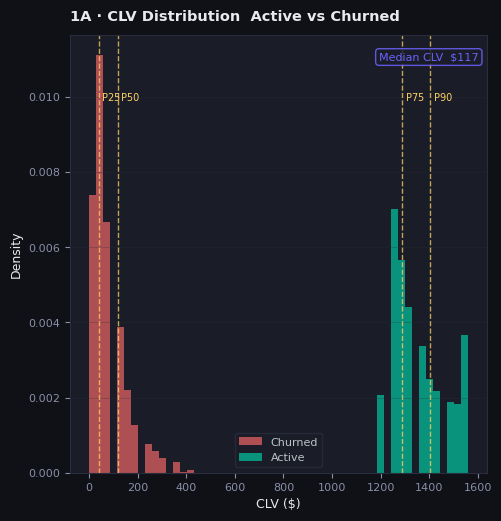

In [57]:
fig1 = plt.figure(figsize=(20, 14), facecolor=BG)

gs = GridSpec(2, 3, fig1, hspace=0.46, wspace=0.36)
ax = style(fig1.add_subplot(gs[0, 0]), '1A · CLV Distribution  Active vs Churned')
clv_cap = df['clv_per_customer'].quantile(0.97)
bins    = np.linspace(0, clv_cap, 55)
ax.hist(churned_df['clv_per_customer'].clip(upper=clv_cap),
        bins=bins, color=V3, alpha=0.65, label='Churned', density=True)
ax.hist(active_df['clv_per_customer'].clip(upper=clv_cap),
        bins=bins, color=V2, alpha=0.65, label='Active',  density=True)
ylim_top = ax.get_ylim()[1]
for p, lbl in [(25,'P25'), (50,'P50'), (75,'P75'), (90,'P90')]:
    v = np.percentile(df['clv_per_customer'], p)
    ax.axvline(v, color=V4, lw=1, ls='--', alpha=0.75)
    ax.text(v + clv_cap * 0.01, ylim_top * 0.85, lbl,
            color=V4, fontsize=7, ha='left')
ax.set_xlabel('CLV ($)'); ax.set_ylabel('Density')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
tag(ax, f"Median CLV  ${df['clv_per_customer'].median():.0f}")


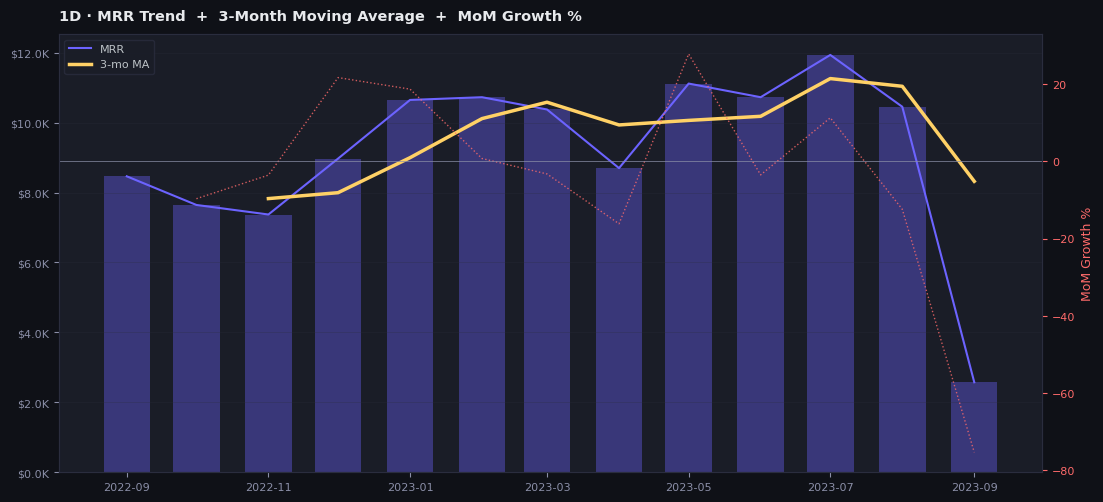

In [58]:

fig1 = plt.figure(figsize=(20, 14), facecolor=BG)

ax = style(fig1.add_subplot(gs[1, :2]),
           '1D · MRR Trend  +  3-Month Moving Average  +  MoM Growth %')
mrr = (df[df['was_subscription_paid']]
       .groupby(df['created_date'].dt.to_period('M'))['monthly_revenue']
       .sum().sort_index())
mrr.index = mrr.index.to_timestamp()
ma3 = mrr.rolling(3).mean()
mom = mrr.pct_change() * 100
ax.bar(mrr.index, mrr.values, width=20, color=V1, alpha=0.38)
ax.plot(mrr.index, mrr.values, color=V1, lw=1.5, label='MRR')
ax.plot(ma3.index, ma3.values, color=V4, lw=2.5, label='3-mo MA')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.1f}K'))
ax2 = ax.twinx()
ax2.plot(mrr.index, mom, color=V3, lw=1, ls=':', alpha=0.8)
ax2.axhline(0, color=MUTE, lw=0.5)
ax2.set_ylabel('MoM Growth %', color=V3, fontsize=9)
ax2.tick_params(axis='y', colors=V3); ax2.set_facecolor(CARD)
ax.legend(fontsize=8, loc='upper left'); ax.grid(axis='y', alpha=0.3)

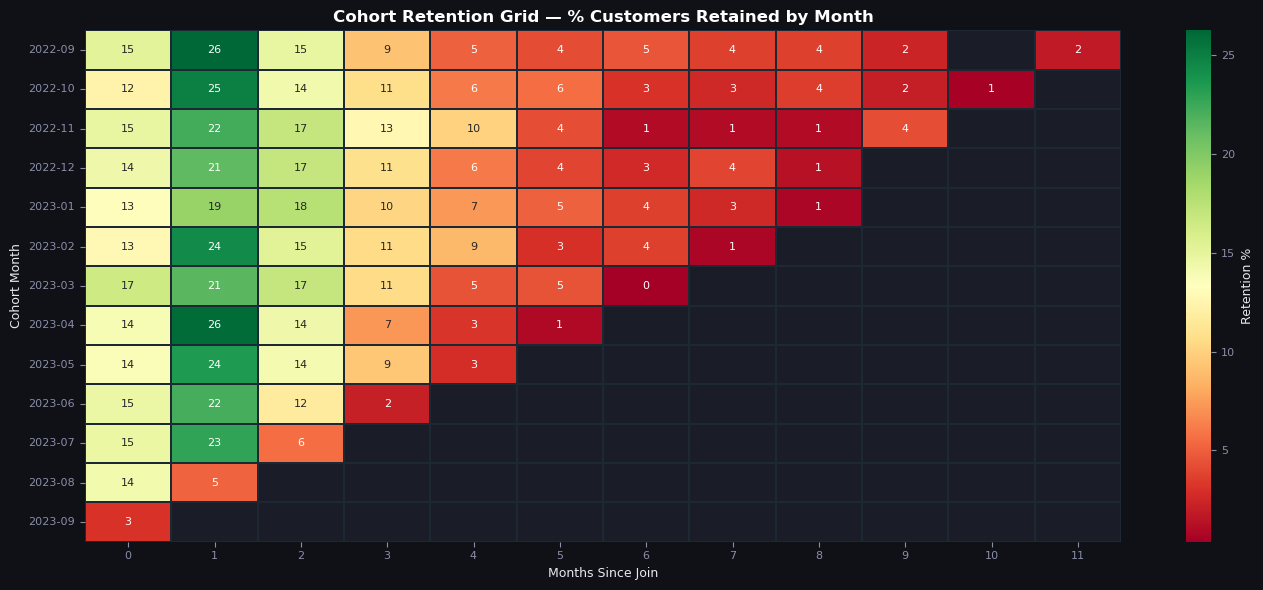

In [61]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 6))
df['months_since_join'] = pd.to_numeric(df['months_since_join'], errors='coerce').fillna(0).astype(int)
df_churned = df[df['churn_flag']==1].copy()
cohort_counts = df.groupby('cohort_month')['customer_id'].count()
cohort_grid   = df_churned.groupby(['cohort_month','months_since_join'])['customer_id'].count().unstack(fill_value=0)
retention     = cohort_grid.divide(cohort_counts, axis=0).fillna(0) * 100
retention     = retention.iloc[:, :13]
mask = retention == 0
sns.heatmap(retention, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.3, linecolor='#1C2833',
            annot_kws={'size':8}, ax=ax, mask=mask,
            cbar_kws={'label':'Retention %'})
ax.set_title('Cohort Retention Grid — % Customers Retained by Month')
ax.set_xlabel('Months Since Join')
ax.set_ylabel('Cohort Month')
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8, rotation=0)
plt.tight_layout()
plt.savefig('chart_04_cohort_retention.png', dpi=150, bbox_inches='tight', facecolor='#1C2833')
plt.show()

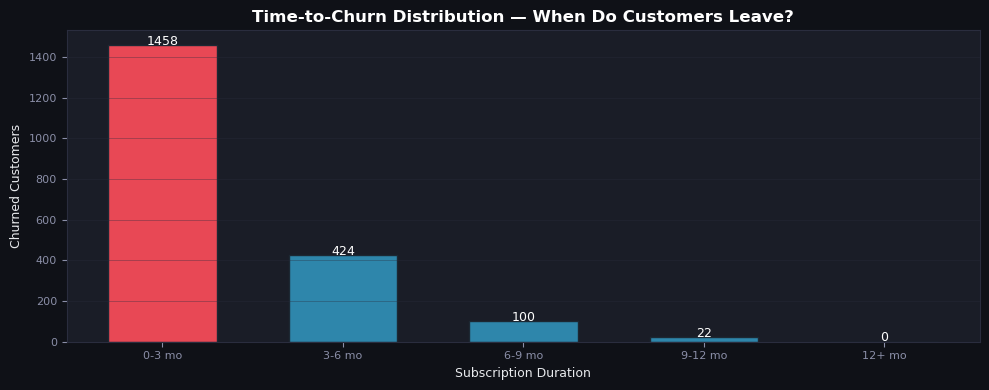

In [65]:
fig, ax = plt.subplots(figsize=(10, 4))
dur = df[df['churn_flag']==1]['subscription_duration']
bins = [0, 3, 6, 9, 12, 100]
labels = ['0-3 mo','3-6 mo','6-9 mo','9-12 mo','12+ mo']
df['dur_bucket'] = pd.cut(df['subscription_duration'], bins=bins, labels=labels, right=False)
bucket_counts = df[df['churn_flag']==1]['dur_bucket'].value_counts().reindex(labels, fill_value=0)
bar_colors = [RED if bucket_counts[l] == bucket_counts.max() else BLUE for l in labels]
bars = ax.bar(labels, bucket_counts.values, color=bar_colors, width=0.6, edgecolor='#1C2833')
ax.set_title('Time-to-Churn Distribution — When Do Customers Leave?')
ax.set_xlabel('Subscription Duration')
ax.set_ylabel('Churned Customers')
ax.grid(True, axis='y')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            str(int(bar.get_height())), ha='center', fontsize=9, color=WHITE)
plt.tight_layout()
plt.savefig('chart_08_duration_distribution.png', dpi=150, bbox_inches='tight', facecolor='#1C2833')
plt.show()

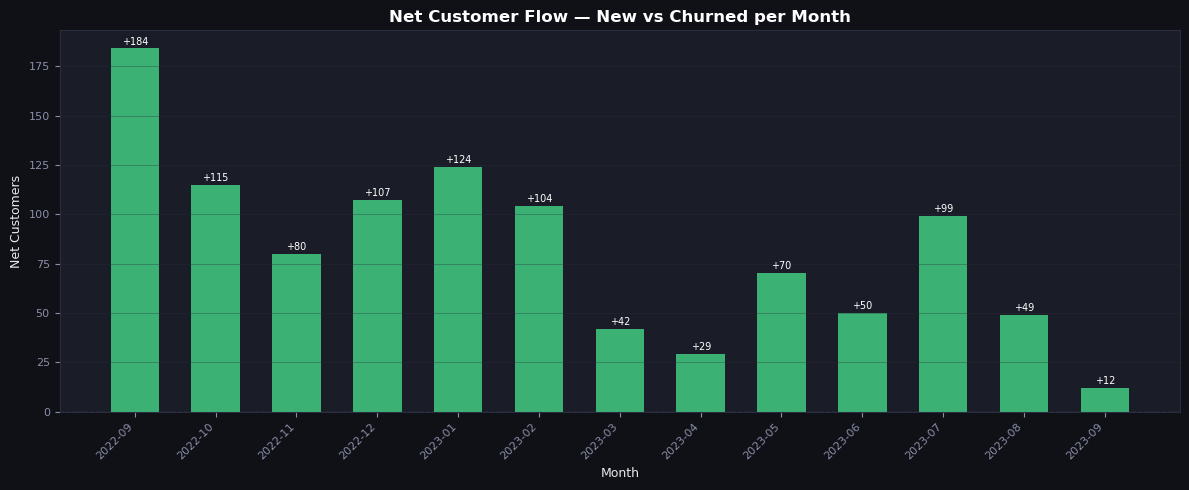

In [64]:
fig, ax = plt.subplots(figsize=(12, 5))
new_c   = df.groupby('cohort_month')['customer_id'].count().reset_index().sort_values('cohort_month')
churn_c = df[df['churn_flag']==1].groupby('cancel_month')['customer_id'].count().reset_index()
churn_c = churn_c[churn_c['cancel_month'] != 'None'].rename(columns={'cancel_month':'cohort_month','customer_id':'churned'})
flow    = new_c.merge(churn_c, on='cohort_month', how='left').fillna(0)
flow['net'] = flow['customer_id'] - flow['churned']
colors  = [GREEN if v >= 0 else RED for v in flow['net']]
bars    = ax.bar(range(len(flow)), flow['net'], color=colors, width=0.6)
ax.axhline(0, color=LIGHT, linewidth=0.8, linestyle='--')
ax.set_xticks(range(len(flow)))
ax.set_xticklabels(flow['cohort_month'], rotation=45, ha='right')
ax.set_title('Net Customer Flow — New vs Churned per Month')
ax.set_xlabel('Month')
ax.set_ylabel('Net Customers')
ax.grid(True, axis='y')
for i, (bar, val) in enumerate(zip(bars, flow['net'])):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() + (1 if val>=0 else -3),
            f'{int(val):+}', ha='center', va='bottom', fontsize=7, color=WHITE)
plt.tight_layout()
plt.savefig('chart_03_net_flow.png', dpi=150, bbox_inches='tight', facecolor='#1C2833')
plt.show()


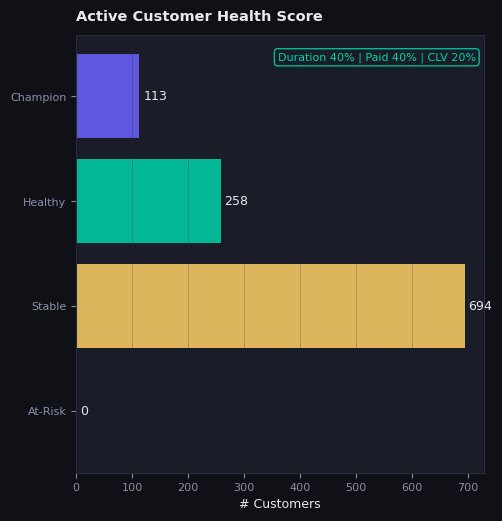

In [68]:
fig3 = plt.figure(figsize=(20, 14), facecolor=BG)

gs = GridSpec(2, 3, fig3, hspace=0.46, wspace=0.40)

ax = style(fig3.add_subplot(gs[0, 2]), 'Active Customer Health Score')
adf = active_df.copy()
def norm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-9)
adf['health'] = (norm(adf['subscription_duration']) * 0.40
                 + adf['was_subscription_paid'].astype(float) * 0.40
                 + norm(adf['clv_per_customer']) * 0.20)
h_bins = [0, 0.30, 0.60, 0.80, 1.01]
h_lbls = ['At-Risk', 'Stable', 'Healthy', 'Champion']
h_cols = [V3, V4, V2, V1]
adf['h_seg'] = pd.cut(adf['health'], bins=h_bins, labels=h_lbls, right=False)
counts = adf['h_seg'].value_counts().reindex(h_lbls).fillna(0).astype(int)
bars = ax.barh(h_lbls, counts.values, color=h_cols, alpha=0.85)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_width() + max(counts.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            str(v), va='center', fontsize=9)
ax.set_xlabel('# Customers'); ax.grid(axis='x', alpha=0.3)
tag(ax, 'Duration 40% | Paid 40% | CLV 20%', V2)



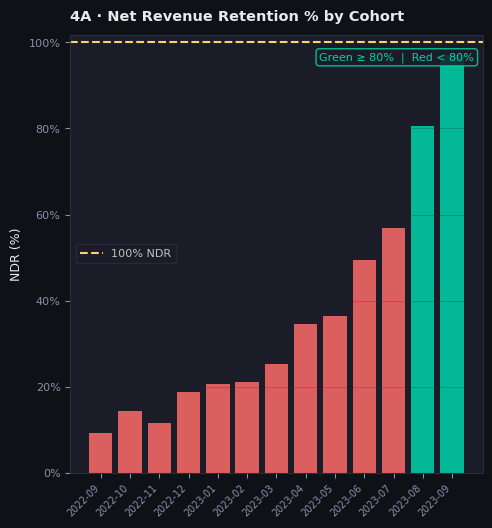

In [73]:
fig4 = plt.figure(figsize=(20, 14), facecolor=BG)

gs = GridSpec(2, 3, fig4, hspace=0.46, wspace=0.38)

# 4A · Net Revenue Retention by Cohort
ax = style(fig4.add_subplot(gs[0, 0]), '4A · Net Revenue Retention % by Cohort')
cohort_rev = (df.groupby('cohort_month', observed=True)
                .apply(lambda g: pd.Series({
                    'start_rev':   g['monthly_revenue'].sum(),
                    'current_rev': g.loc[g['active_flag'] == 1,
                                         'monthly_revenue'].sum(),
                }), include_groups=False)
                .dropna())
cohort_rev['ndr'] = (cohort_rev['current_rev']
                     / cohort_rev['start_rev'].replace(0, np.nan) * 100)
recent = cohort_rev.dropna(subset=['ndr']).iloc[-18:]
bar_c  = [V2 if v >= 80 else V3 for v in recent['ndr'].values]
ax.bar(range(len(recent)), recent['ndr'].values, color=bar_c, alpha=0.85)
ax.axhline(100, color=V4, lw=1.5, ls='--', label='100% NDR')
ax.set_xticks(range(len(recent)))
ax.set_xticklabels([str(c) for c in recent.index],
                   rotation=45, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('NDR (%)'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
tag(ax, 'Green ≥ 80%  |  Red < 80%', V2)


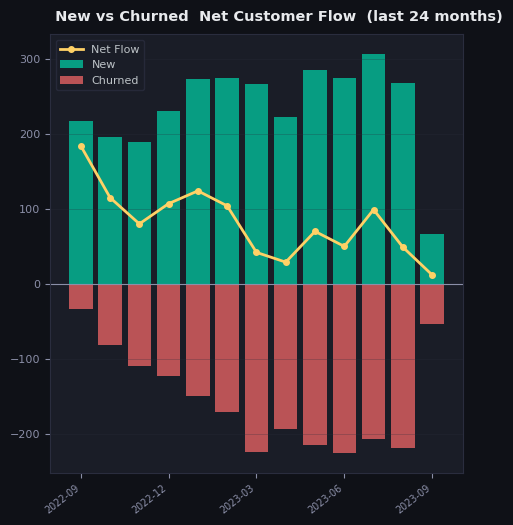

In [74]:
fig4 = plt.figure(figsize=(20, 14), facecolor=BG)
gs = GridSpec(2, 3, fig4, hspace=0.46, wspace=0.38)

ax = style(fig4.add_subplot(gs[0, 1]),
           ' New vs Churned  Net Customer Flow  (last 24 months)')
new_mo = (df.groupby(df['created_date'].dt.to_period('M'))['customer_id']
            .count().sort_index())
cancel_mask = df['canceled_date'].notna()
churn_mo    = (df[cancel_mask]
               .groupby(df.loc[cancel_mask, 'canceled_date'].dt.to_period('M'))
               ['customer_id'].count().sort_index())
all_p    = sorted(set(new_mo.index) | set(churn_mo.index))
new_mo   = new_mo.reindex(all_p, fill_value=0)
churn_mo = churn_mo.reindex(all_p, fill_value=0)
net_flow = new_mo - churn_mo
periods  = all_p[-24:]
nv = new_mo.reindex(periods, fill_value=0).values
cv = churn_mo.reindex(periods, fill_value=0).values
fv = net_flow.reindex(periods, fill_value=0).values
xi = list(range(len(periods)))
ax.bar(xi,  nv, color=V2, alpha=0.7, label='New')
ax.bar(xi, -cv, color=V3, alpha=0.7, label='Churned')
ax.plot(xi, fv, 'o-', color=V4, lw=2, ms=4, label='Net Flow')
ax.axhline(0, color=MUTE, lw=0.8)
ax.set_xticks(xi[::3])
ax.set_xticklabels([str(p) for p in periods[::3]],
                   rotation=38, ha='right', fontsize=7)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)


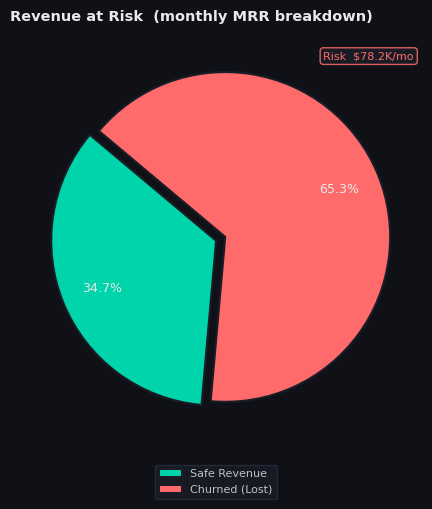

In [78]:
fig4 = plt.figure(figsize=(20, 14), facecolor=BG)
gs = GridSpec(2, 3, fig4, hspace=0.46, wspace=0.38)

ax = style(fig4.add_subplot(gs[1, 2]),
           'Revenue at Risk  (monthly MRR breakdown)')
safe   = df[(df['active_flag']==1) &  df['was_subscription_paid']]['monthly_revenue'].sum()
unpaid = df[(df['active_flag']==1) & ~df['was_subscription_paid']]['monthly_revenue'].sum()
lost   = df[df['churn_flag']==1]['monthly_revenue'].sum()
sizes  = [safe, unpaid, lost]
labels = ['Safe Revenue', 'Active-Unpaid (At Risk)', 'Churned (Lost)']
non_zero = [(s, l, c) for s, l, c in zip(sizes, labels, [V2, V4, V3]) if s > 0]
if non_zero:
    sz, lb, co = zip(*non_zero)
    wedges, _, autotexts = ax.pie(
        sz, labels=None, colors=co, autopct='%1.1f%%',
        startangle=140,
        explode=[0.06 if i > 0 else 0 for i in range(len(sz))],
        wedgeprops=dict(linewidth=1.5, edgecolor=CARD),
        pctdistance=0.75,
    )
    for at in autotexts:
        at.set_fontsize(9); at.set_color(TXT)
    ax.legend(lb, fontsize=8, loc='lower center',
              bbox_to_anchor=(0.5, -0.14), ncol=1)
tag(ax, f"Risk  ${(unpaid + lost)/1000:.1f}K/mo", V3)
